# Visualisasi Hasil Skripsi (Real Data Pipeline + Retrieval Augmented)

Notebook ini memvisualisasikan hasil prediksi **Probabilistic Nowcasting** menggunakan data aktual (ERA5) dan model Diffusion yang telah dilatih dengan mekanisme **Retrieval Augmented**.


In [4]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.inference import load_model_and_stats, run_inference_real

sns.set_theme(style="whitegrid")

## 1. Load Real Data & Model & Retrieval Database
Mengambil data test dari dataset ERA5 asli (2005-2025), memuat checkpoint model, dan membangun ulang index Retrieval (FAISS).

In [5]:
# Load Checkpoint and Rebuild Index
try:
    model, stats, retrieval_db = load_model_and_stats("../models/diffusion_chkpt.pth")
    print("\nSystem Ready.")
except Exception as e:
    print(f"CRITICAL: {e}")
    print("Please run 'python src/train.py' in the terminal first to generate the model!")

# Load Real Data for Testing
data_path = '../data/raw/sitaro_era5_2005_2025.parquet'
if os.path.exists(data_path):
    df = pd.read_parquet(data_path)
    print(f"Data loaded. Total Rows: {len(df)}")
    
    # Select a specific 'Rain Event' for visualization
    # Let's find a time window where it actually rained > 5mm
    rain_events = df[df['precipitation'] > 5.0]
    if not rain_events.empty:
        start_idx = rain_events.index[0]
        # Take 6 hours window
        test_slice = df.iloc[start_idx:start_idx+6]
    else:
        test_slice = df.iloc[0:6]
        print("No heavy rain found, showing first 6 hours.")
else:
    print("Data not found! Run 'python src/data/ingest.py' first.")
    test_slice = pd.DataFrame()

Model loaded successfully.
Rebuilding Retrieval Index for Inference...
Retrieval Index Ready.

System Ready.
Data loaded. Total Rows: 552240


d:\SKRIPSI\Skripsi_Bevan\src\inference.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path)


## 2. Generate Real Probabilistic Forecasts
Melakukan inferensi langsung ke model. Model akan secara otomatis **mencari 3 hari masa lalu yang mirip** (Retrieval) sebelum menghasilkan prediksi.

In [6]:
predictions = []
ground_truth = []
timesteps_label = []

# Features needed for inference
feature_cols = ['temperature_2m', 'relative_humidity_2m', 'surface_pressure', 'wind_speed_10m', 'wind_direction_10m']

print("Running Inference...")
for i, row in test_slice.iterrows():
    # Prepare input
    # Cast to float explicitly because iterrows() might create object Series if dataframe has mixed types
    features_val = row[feature_cols].values.astype(float)
    features = torch.tensor(features_val, dtype=torch.float32).unsqueeze(0)
    
    # Normalize features using saved stats
    c_mean = stats['c_mean']
    c_std = stats['c_std']
    features_norm = (features - c_mean) / (c_std + 1e-5)
    
    # Run Inference (50 samples)
    # Now passing retrieval_db explicitly
    preds = run_inference_real(features_norm, model, stats, retrieval_db)
    predictions.append(preds)
    ground_truth.append(row['precipitation'])
    timesteps_label.append(str(row.name) if 'date' not in row else str(row['date']))

predictions = np.array(predictions) # [Timesteps, Samples]
ground_truth = np.array(ground_truth)
timesteps = np.arange(len(ground_truth))

Running Inference...


## 3. Visualization
Plotting hasil Real Data.

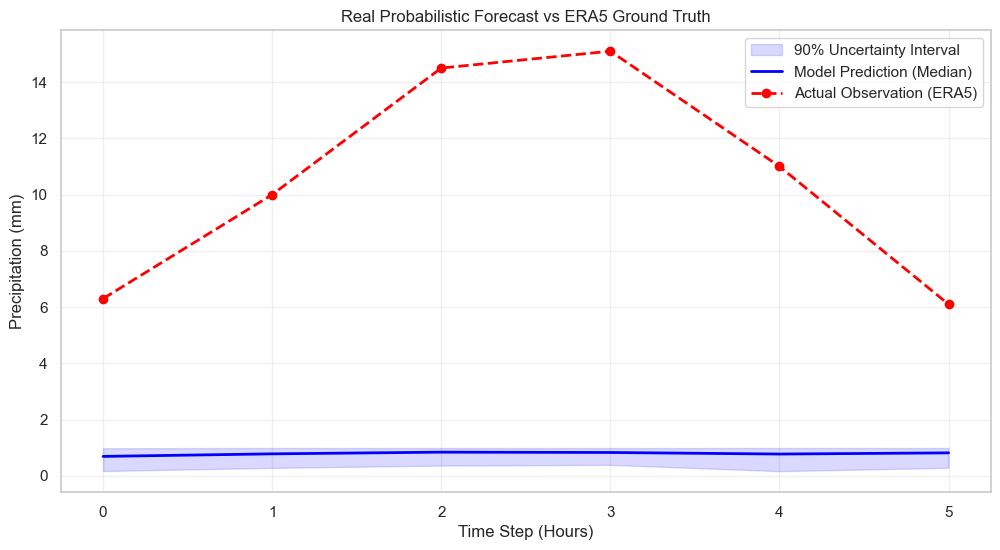

In [7]:
plt.figure(figsize=(12, 6))

median = np.median(predictions, axis=1)
lower_90 = np.percentile(predictions, 5, axis=1)
upper_90 = np.percentile(predictions, 95, axis=1)

# Uncertainty Band
plt.fill_between(timesteps, lower_90, upper_90, color='blue', alpha=0.15, label='90% Uncertainty Interval')

# Median & GT
plt.plot(timesteps, median, color='blue', linewidth=2, label='Model Prediction (Median)')
plt.plot(timesteps, ground_truth, color='red', linestyle='--', linewidth=2, marker='o', label='Actual Observation (ERA5)')

plt.title(f'Real Probabilistic Forecast vs ERA5 Ground Truth')
plt.xlabel('Time Step (Hours)')
plt.ylabel('Precipitation (mm)')
plt.legend()
plt.grid(True, alpha=0.3)

# plt.xticks(timesteps, [t[11:16] for t in timesteps_label]) # Show HH:MM
plt.show()